## Этап 3: Кластеризация клиентов (K-Means)

**Задача:** разбить клиентов на сегменты по поведению (RFM-метрики), 
без какой-либо предварительной разметки, используя unsupervised 
обучение (K-Means).

**План работы:**
1. Загрузить RFM-таблицу, посчитанную на предыдущем этапе
2. Нормализовать метрики (Recency, Frequency, Monetary) через StandardScaler
3. Подобрать оптимальное число кластеров K с помощью метода локтя и 
   метода силуэтов
4. Обучить финальную модель и проанализировать результат — проверить 
   баланс размеров кластеров и адекватность разделения
5. Дать каждому кластеру понятную интерпретацию на основе средних 
   значений RFM
6. Визуализировать результат и сохранить таблицу с присвоенными 
   кластерами для дальнейшего использования (предсказание оттока)

In [233]:
# Импорты нужных библиотек 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [234]:
# Считывание RFM таблицы которую мы сохраняли в конце предыдущего шага
rfm = pd.read_csv('../data/processed/rfm.csv')

In [235]:
# Нормализация данных по нужным признакам, колонку 'Customer ID' не трогаем
scaler = StandardScaler()
scaled_X = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

scaled_X

array([[-0.89367394, -0.34046981, -0.07538791],
       [-0.15181298, -0.43902565, -0.2035101 ],
       [-0.47572411, -0.14335813,  0.07862376],
       ...,
       [ 2.16780861, -0.43902565, -0.17967655],
       [ 0.24523936, -0.24191397, -0.09108264],
       [-0.73694276, -0.04480229,  0.04297583]], shape=(4283, 3))

In [236]:
# Используем метод локтя: обучаем KMeans с разным числом кластеров K (от 2 до 9)
# для каждого записываем inertia 

# inertia = ssd(sum of squared distances) = сумму квадратов расстояний точек до центроида своего кластера
ssd = []

for k in range(2,10):
    model = KMeans(n_clusters=k, random_state=44, n_init=10)
    model.fit(scaled_X)

    ssd.append(model.inertia_)

Text(0.5, 1.0, 'Метод локтя')

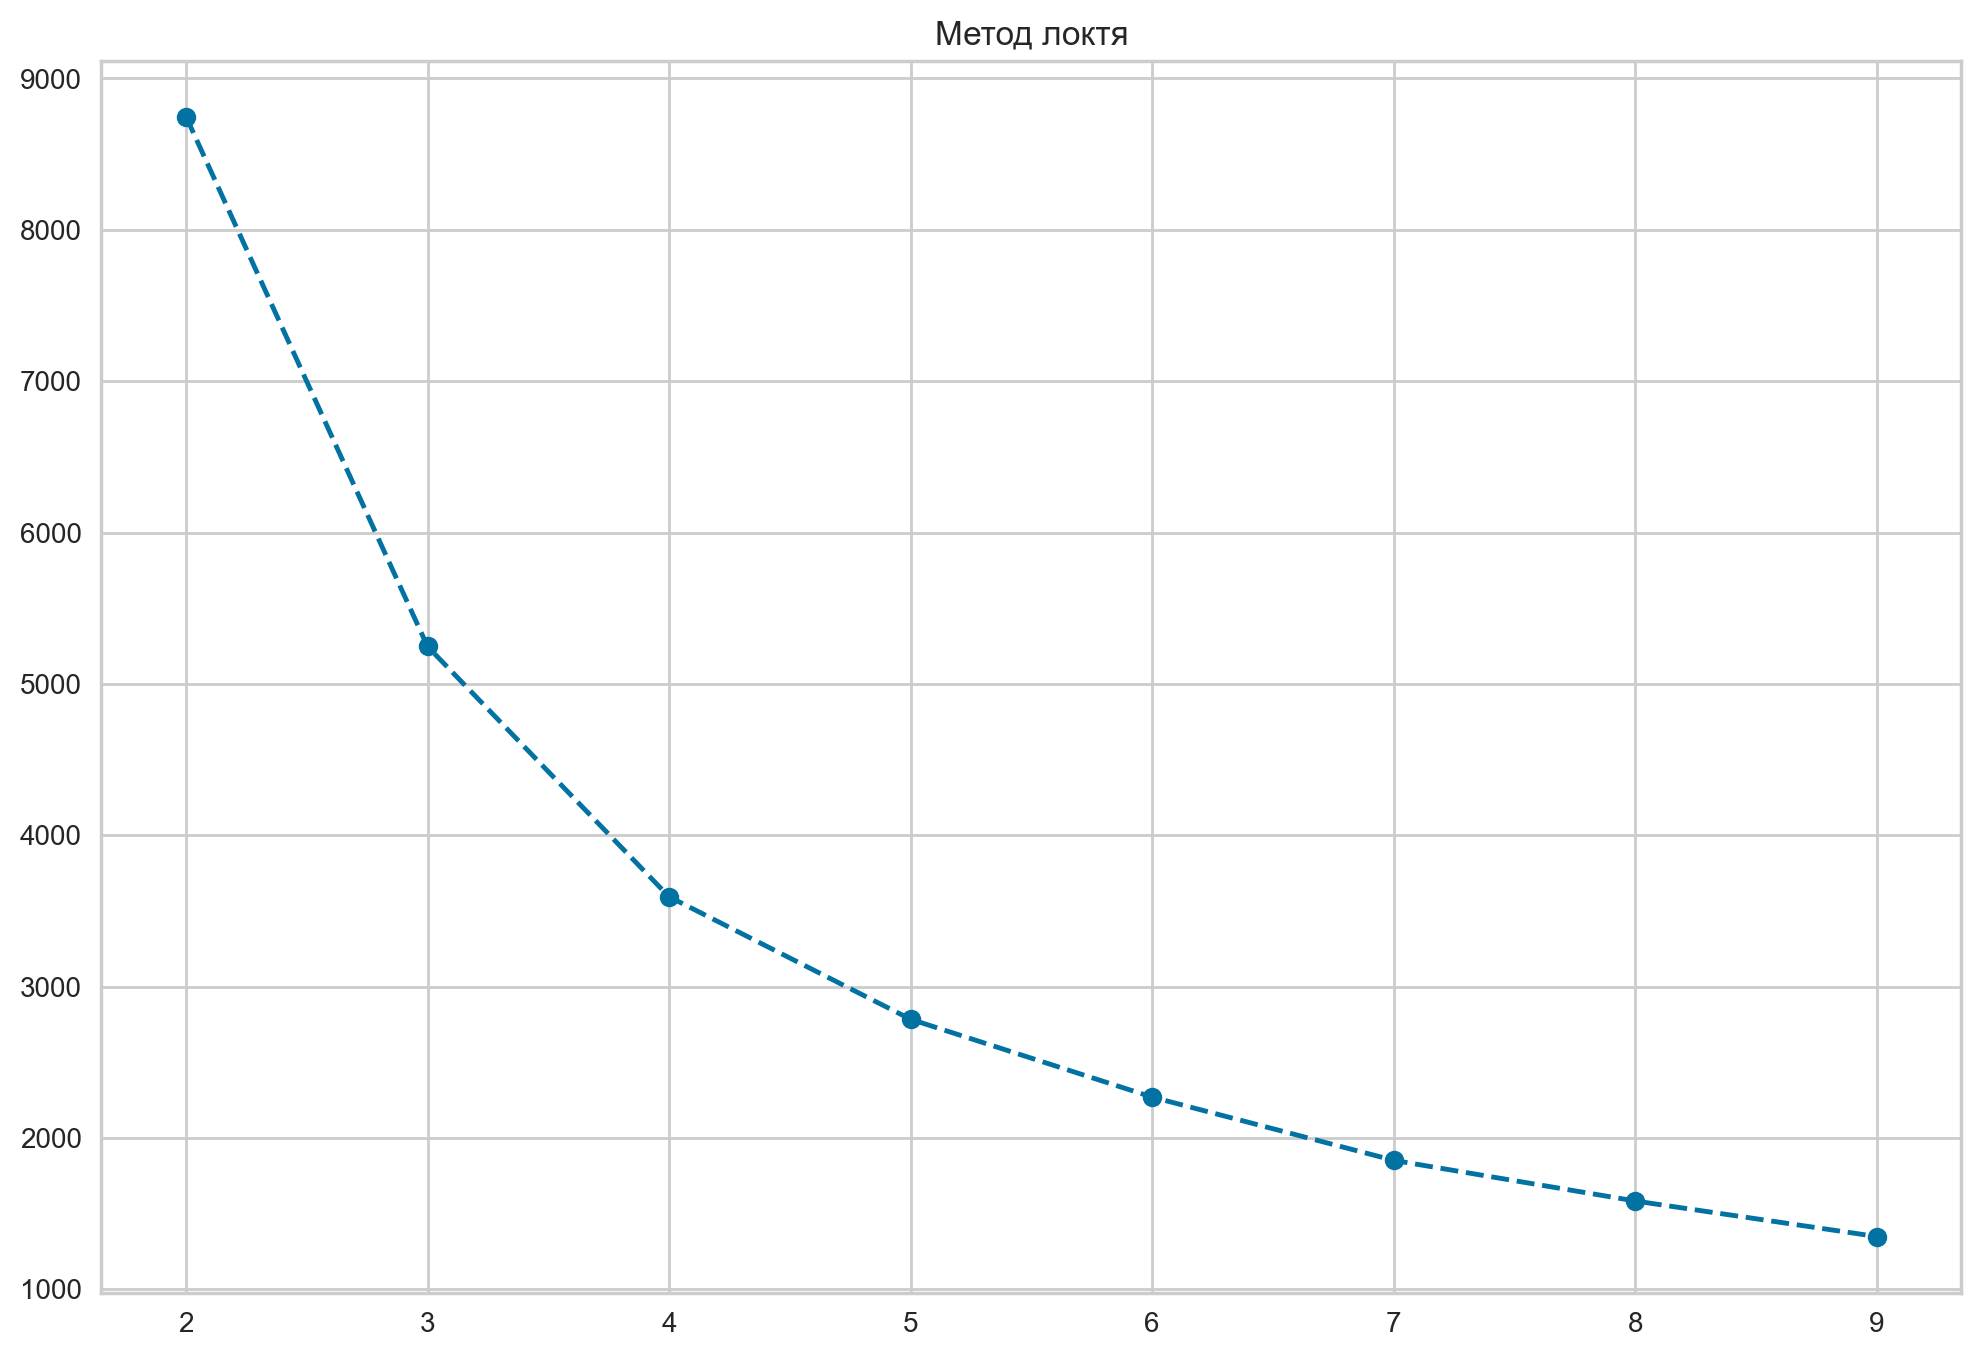

In [237]:
# график показывает inertia для K от 2 до 9
# Видим излом ("локоть") около K = 4-5
plt.figure(figsize=(12,8),dpi=200)
plt.plot(range(2,10),ssd,'o--')
plt.title('Метод локтя')

In [238]:
# Метод силуэтов: дополнительная проверка качества кластеризации 
# В отличие от inertia, здесь ищем максимум, а не "локоть"  
# более высокое значение означает более чёткое разделение кластеров.
silhouettes = []

for k in range(2,10):
    model = KMeans(n_clusters=k, random_state=44, n_init=10)
    model.fit(scaled_X)

    silhouettes.append(silhouette_score(scaled_X,model.labels_))

Text(0.5, 1.0, 'Метод силуэтов')

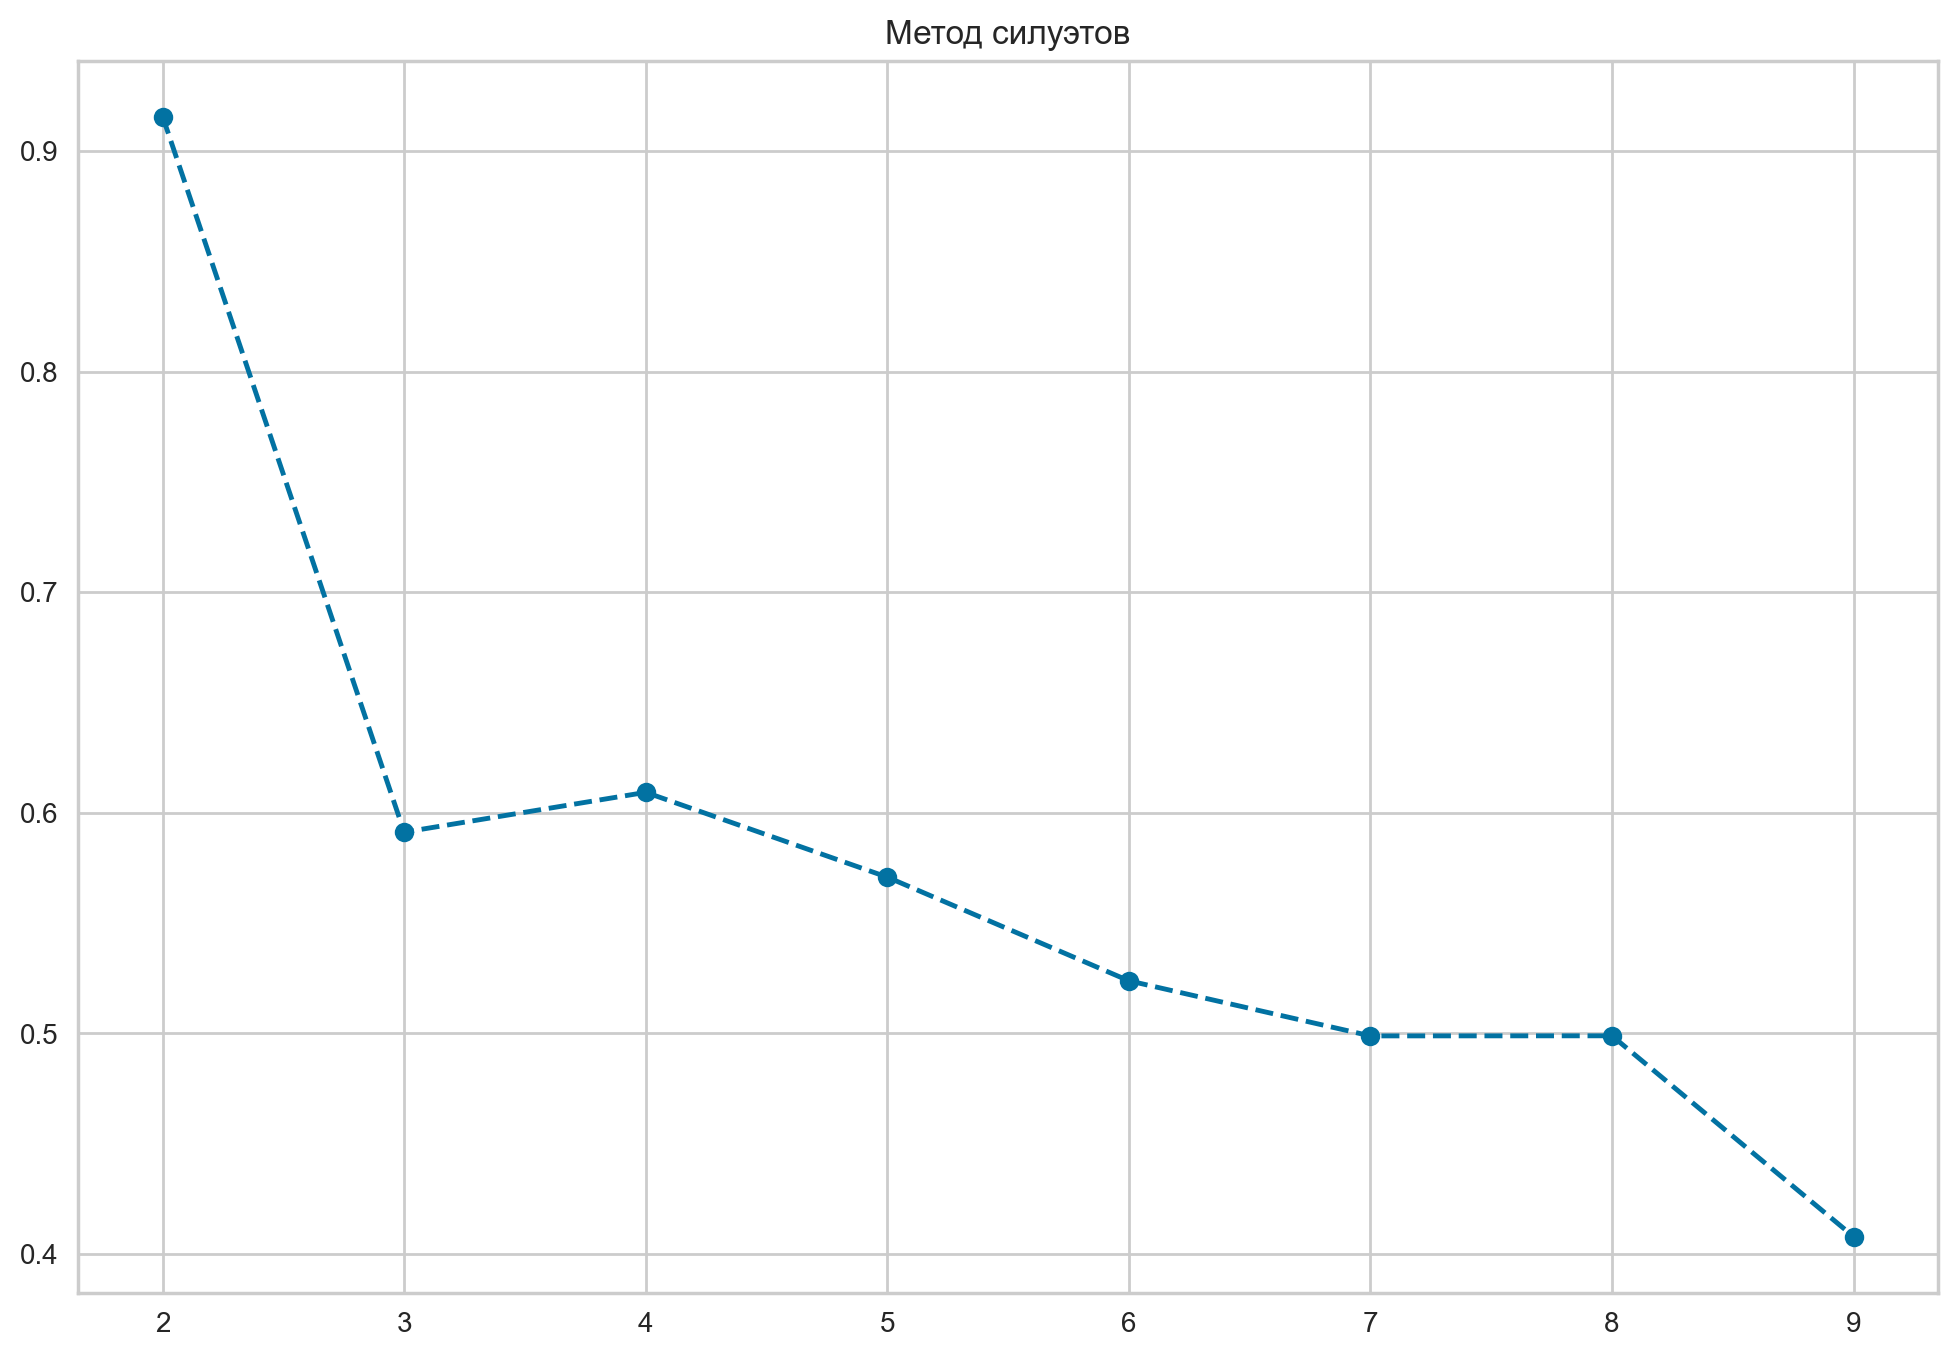

In [239]:
# Самое высокое значение мы видим в точке K = 2 но это очень мало кластеров для нашей задачи
# это буквально разделение на плохих и хороших клиентов поэтому принято решение взять K = 4 
# так как там 2ой по величине максимум
plt.figure(figsize=(12,8),dpi=200)
plt.plot(range(2,10),silhouettes,'o--')
plt.title('Метод силуэтов')

In [240]:
# Обучаем модель с самым оптимальным для нашей задачи K

model = KMeans(n_clusters=4, random_state=44, n_init=10)
model.fit(scaled_X)
pred = model.predict(scaled_X)

In [241]:
# Выводим предикты модели и видим огромный дисбаланс кластеров
# скорее всего из за того что он пытается создать кластер вокруг выбросов
# нужно проанализировать таблицу RFM на выбросы
rfm['Cluster'] = pred
print(rfm['Cluster'].value_counts())
print(rfm.head(20))

Cluster
0    3204
1    1020
2      54
3       5
Name: count, dtype: int64
    Customer ID  Recency  Frequency  Monetary  Cluster
0       12347.0        3          2   1323.32        0
1       12348.0       74          1    222.16        0
2       12349.0       43          4   2646.99        0
3       12351.0       11          1    300.93        0
4       12352.0       11          2    343.80        0
5       12353.0       44          1    317.76        0
6       12355.0      203          1    488.21        1
7       12356.0       16          3   3562.25        0
8       12357.0       24          2  12079.99        0
9       12358.0       11          3   2719.01        0
10      12359.0       61          8   2469.36        0
11      12360.0       15          6   1550.83        0
12      12361.0       98          3    321.35        0
13      12362.0      374          1    130.00        1
14      12366.0      269          1    500.24        1
15      12368.0      264          1    917.70 

In [242]:
# Смотрим описание таблицы 
# в колонках Frequency и Monetary видим огромную разницу между 75ми квартильями и максимальными значениями
# у Frequency 75% значений находятся ниже 6 а максимальное значение 270!!! разница в 45 раз
# у Monetary все еще хуже 75% значений находятся ниже 1680 а максимальное значение 341776, разница почти в 200 раз
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4283.000000,4283.000000,4.283000e+03
mean,88.529302,5.454588,1.971250e+03
std,95.716440,10.147717,8.595612e+03
min,1.000000,1.000000,8.881784e-16
25%,17.000000,1.000000,3.036600e+02
50%,50.000000,3.000000,6.865400e+02
75%,130.000000,6.000000,1.683525e+03
max,374.000000,270.000000,3.417767e+05


In [243]:
# Удаление выбросов методом IQR

# Используем межквартильный размах (IQR) для определения выбросов в Frequency и Monetary
# Верхняя граница = Q3 + 1.5 * IQR - стандартный статистический метод (правило Тьюки)
# Recency не обрабатываем, большое значение там естественно отражает давно неактивных клиентов, а не аномалию данных
m_Q1 = rfm['Monetary'].quantile(0.25)
m_Q3 = rfm['Monetary'].quantile(0.75)

f_Q1 = rfm['Frequency'].quantile(0.25)
f_Q3 = rfm['Frequency'].quantile(0.75)

m_IQR = m_Q3 - m_Q1
f_IQR = f_Q3 - f_Q1

upper_bound_m = m_Q3 + 1.5 * m_IQR
upper_bound_f = f_Q3 + 1.5 * f_IQR

rfm_clean = rfm[(rfm['Monetary'] < upper_bound_m) & (rfm['Frequency'] < upper_bound_f)].copy()

print(rfm_clean.shape)
print(rfm.shape)
# Избавились от 500 выбросов!

(3781, 5)
(4283, 5)


In [244]:
# Убираем колонку 'Cluster' так как сейчас мы будем делать повторное распределение точек
rfm_clean = rfm_clean.drop(columns=['Cluster'], errors='ignore')
rfm = rfm.drop(columns=['Cluster'], errors='ignore')

In [245]:
# Выполняем масштабирование уже на новых чистых данных
scaled_clean_X = scaler.fit_transform(rfm_clean[['Recency', 'Frequency', 'Monetary']])
scaled_clean_X

array([[-0.96053578, -0.50536051,  0.58610277],
       [-0.23482256, -0.86903925, -0.80137964],
       [-0.55168326,  0.22199697,  2.253952  ],
       ...,
       [ 2.03430888, -0.86903925, -0.54327737],
       [ 0.15358732, -0.14168177,  0.41613882],
       [-0.80721608,  0.58567571,  1.86790741]], shape=(3781, 3))

Text(0.5, 1.0, 'Метод силуэтов (После очистки)')

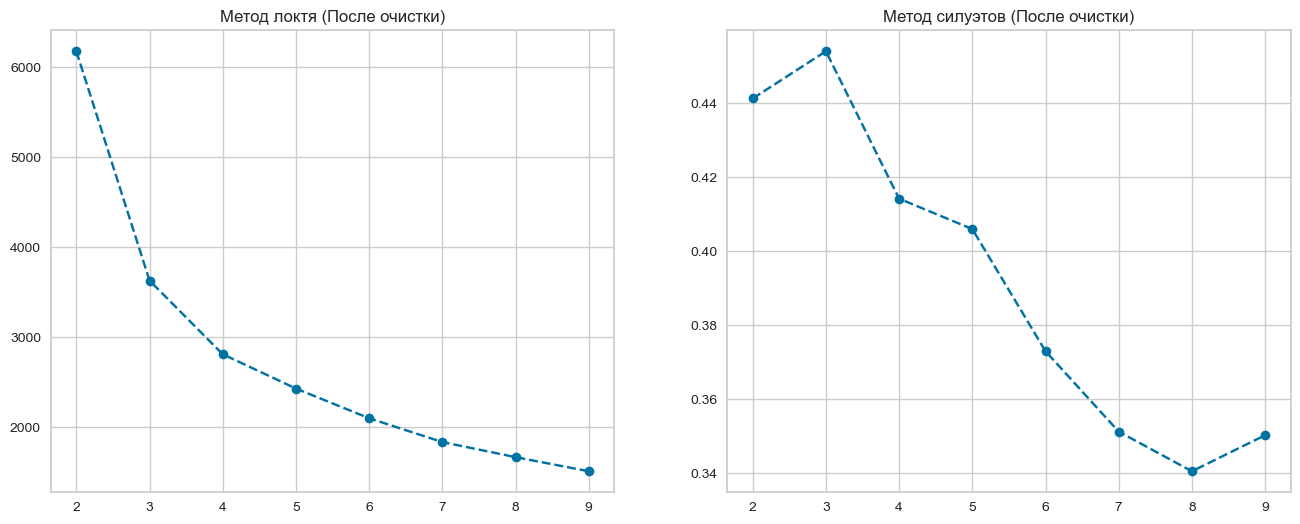

In [246]:
# Выбор K
# снова считаем метрики для выбора оптимального K
# silhouette score максимален при K=3 (0.452), но 
# разница с K=4 (~0.43) небольшая. Выбираем K=4 для большей 
# детализации сегментов - компромисс между математическим качеством 
# и практической ценностью для бизнеса (аналогично решению на 
# исходных данных, где K=2 давал максимум silhouette, но был 
# недостаточно детализирован).
ssd_2 = []
silhouettes_2 = []

for k in range(2,10):
    model_2 = KMeans(n_clusters=k, random_state=44, n_init=10)
    model_2.fit(scaled_clean_X)

    ssd_2.append(model_2.inertia_)
    silhouettes_2.append(silhouette_score(scaled_clean_X,model_2.labels_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(range(2,10), ssd_2, 'o--',)
axes[1].plot(range(2,10), silhouettes_2, 'o--')

axes[0].set_title('Метод локтя (После очистки)')
axes[1].set_title('Метод силуэтов (После очистки)')

In [247]:
# Финально обучаем модель, видим очень сбалансированные кластеры
model_2 = KMeans(n_clusters=4, random_state=44, n_init=10)
predict = model_2.fit_predict(scaled_clean_X)
rfm_clean['Cluster'] = predict
print(rfm_clean['Cluster'].value_counts())

Cluster
0    1543
3     890
2     889
1     459
Name: count, dtype: int64


In [248]:
# Смотрим средние параметры для каждого кластера, после анализа можем четко разделить на группы
rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,53.834089,1.917693,429.419968
1,37.433551,8.673203,2424.065869
2,48.042745,4.965129,1285.546558
3,251.348315,1.642697,367.004149


In [249]:
# Кластер 0 — Recency = недавно, Frequency = редко, Monetary = мало
# Новые/случайные клиенты — низкая активность при относительно свежем визите.

# Кластер 1 — Recency = недавно, Frequency = часто, Monetary = много
# Лояльные клиенты — самые ценные, активные и регулярные покупатели.

# Кластер 2 — Recency = недавно, Frequency = средне, Monetary = средне 
# Средне-активные клиенты — между лояльными и новыми, стабильно покупают но не на уровне топ-группы.

# Кластер 3 — Recency = очень давно, Frequency = редко, Monetary = мало 
# Группа риска — давно не появлялись, и когда были активны — покупали мало.

# Переминовываем кластеры с цифр на понятные обозначения 
cluster_names = {0: 'Новые', 1: 'Лояльные', 2: 'Обычные', 3: 'Группа риска'}
rfm_clean['Cluster_name'] = rfm_clean['Cluster'].map(cluster_names)

Text(0.5, 1.0, 'Размер кластеров')

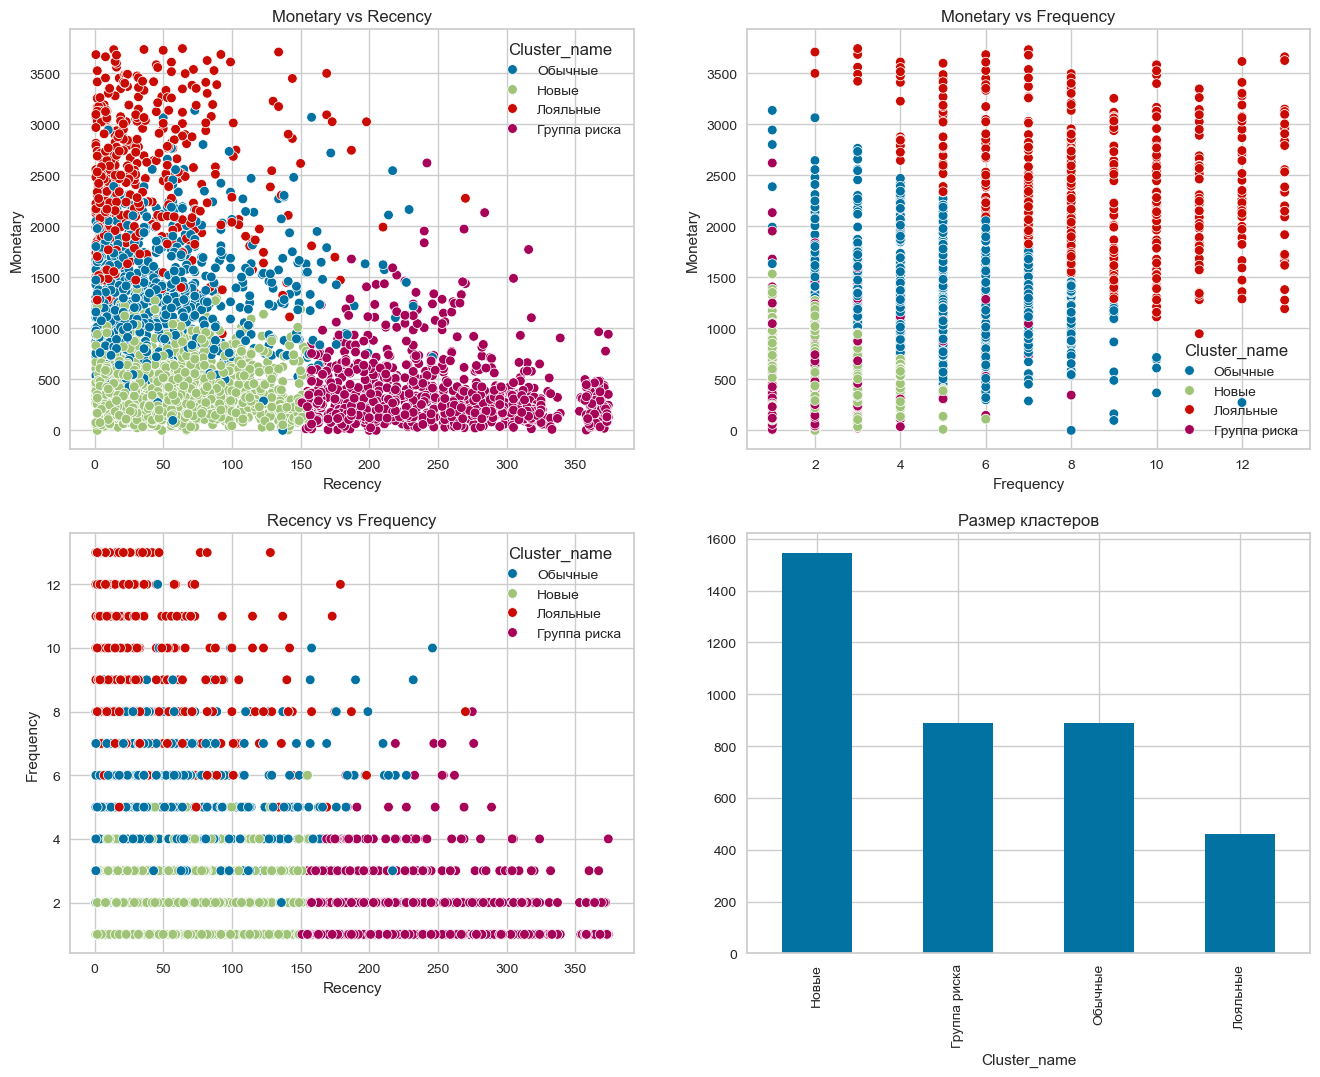

In [250]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.scatterplot(data=rfm_clean,y='Monetary',x='Recency',hue='Cluster_name', ax=axes[0,0])
sns.scatterplot(data=rfm_clean,y='Monetary',x='Frequency',hue='Cluster_name', ax=axes[0,1])
sns.scatterplot(data=rfm_clean, x='Recency', y='Frequency', hue='Cluster_name', ax=axes[1,0])
rfm_clean['Cluster_name'].value_counts().plot(kind='bar', ax=axes[1,1])

axes[0,0].set_title('Monetary vs Recency')
axes[0,1].set_title('Monetary vs Frequency')
axes[1,0].set_title('Recency vs Frequency')
axes[1,1].set_title('Размер кластеров')

In [251]:
# сохрание чистой RFM таблицы с новым столбцом кластеров
rfm_clean.to_csv('../data/processed/rfm_with_clusters.csv', index=False)

## Итог этапа 3

**Что сделано:**

Кластеризация прошла в два прогона. Первый — на исходных RFM-данных — 
дал сильно несбалансированные кластеры (несколько клиентов с 
экстремальными значениями Frequency и Monetary "оттянули" на себя 
отдельные кластеры, оставив основную массу клиентов грубо разделённой 
на 2 группы).

Проблема была диагностирована через `describe()` — разница между 
75-м перцентилем и максимумом по Frequency и Monetary составляла 
45–200 раз. Выбросы удалены методом IQR (правило Тьюки), после чего 
кластеризация повторена на чистых данных — итоговые 4 кластера 
получились сбалансированными.

Финальное число кластеров (K=4) выбрано как компромисс: метод 
силуэтов давал математический максимум при меньшем K (2–3), но это 
не давало достаточной детализации для бизнес-сегментации.

**Результат — 4 сегмента клиентов:**
- Лояльные — недавняя активность, частые покупки, высокий чек
- Обычные — средняя активность по всем трём метрикам
- Новые — недавняя активность, но малое количество покупок (возможно случайные/новые клиенты)
- Группа риска — давно не покупали, исторически низкая активность

**С чем столкнулись:**
- KMeans без `random_state` даёт невоспроизводимые результаты между 
  запусками (разная нумерация кластеров, незначительно разные метрики) — 
  решено фиксацией `random_state` и `n_init=10` во всех вызовах
- Жёсткая привязка имён кластеров к номерам ломается при изменении 
  random_state — для надёжности имена нужно привязывать к 
  отсортированным средним значениям метрик, а не к номеру кластера

**Ограничение скоупа:**

Удалённые на этапе IQR-фильтрации ~502 клиента (12% базы) не являются 
случайным шумом — судя по экстремальным значениям Frequency и Monetary, 
это скорее всего крупные/оптовые покупатели. Они полностью исключены 
из дальнейшего пайплайна: ни кластера, ни предсказания оттока для них 
не будет ни в одной из следующих стадий, включая финальное демо.

Это осознанное решение по скоупу проекта, а не побочный эффект очистки 
данных. При необходимости в будущем эту группу можно обработать 
отдельно (например, как отдельный сегмент "VIP/опт"), но в рамках 
текущей версии проекта она вне фокуса.

**Сохранено:** `data/processed/rfm_with_clusters.csv` — таблица с 
RFM-метриками, номером кластера и его названием, готовая для 
следующего этапа (предсказание оттока).